In [1]:
import os
from pathlib import Path

from astropy.table import Table, join
import numpy as np
from numpy.lib.recfunctions import structured_to_unstructured
import matplotlib.pyplot as plt

from quasarnp.utils import absorber_IGM
import scipy.integrate as integrate

plt.rcParams.update({'font.size': 13})

In [2]:
c_thresh = 0.95
n_thresh = 1

line_names = ["LYA", "CIV", "CIII", "MgII", "HBETA", "HALPHA"]
line_and_wave = ["LYA", "CIV(1548)", "CIII(1909)", "MgII(2796)", "Hbeta", "Halpha"]
line_wavelengths = [absorber_IGM[k]for k in line_and_wave]
c_names = [f"C_{l}" for l in line_names]

In [3]:
data_dir = Path("data/")
table_loc = data_dir / "dr12_all_guadalupe.csv"

In [4]:
def calc_entropy(confidence):
    H = confidence * np.log(confidence) / np.log(2)
    H = np.where(confidence == 0, 0, H)
    return -np.sum(H, axis=1)

In [5]:
old_tbl = Table.read(table_loc)
old_tbl

TARGETID,TILEID,EXPID,C_LYA,C_CIV,C_CIII,C_MgII,C_HBETA,C_HALPHA,C_CIV_BAL,Z_LYA,Z_CIV,Z_CIII,Z_MgII,Z_HBETA,Z_HALPHA,Z_CIV_BAL,ZBEST
int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
39627758518669118,1000,89031,0.0016741289942648458,0.04020673444509168,0.92106447396715,0.9417525981257873,3.7649795831047e-05,3.99492223114839e-05,1.7844302480932927e-05,2.8402121837990126,1.519256155702168,1.483717641839097,1.496563806623815,0.24593487054342988,0.042819886712210264,4.474599877185332,1.496563806623815
39627764562658182,1000,89031,1.513061519365129e-06,8.044658981381805e-06,2.5685893946577576e-06,6.156486392023656e-06,3.774063813109704e-06,1.6390029416257317e-05,2.2142878292050416e-06,7.103563988016338,1.4042756767111815,1.100412430439854,1.6834193192018136,0.9739357915777567,0.13892008254105415,2.879963211840485,0.13892008254105415
39627764562660466,1000,89031,0.999999959073144,0.9999999687015929,0.9999999215870486,6.154147564047898e-06,2.135690120287605e-05,4.946267475565533e-06,0.0003861174031670185,3.2592381456945683,3.2614181609636983,3.2612887149494894,0.36890734007405634,0.17076632291093818,0.2560947327736458,3.2365810630177947,3.2614181609636983
39627764566852122,1000,89031,0.0049681788976327365,0.00884003976666149,0.0003201414947522075,0.0002849358570249137,3.942677882887877e-06,1.186172399756724e-06,6.771197160552499e-05,2.6419373888890694,2.645754894367178,2.6263109229314847,2.1435270342972563,0.1358009720789184,-0.4321829620446319,2.6173846860058405,2.645754894367178
39627764566854344,1000,89031,0.0020933590329048585,0.0005639932024836017,0.04024205247576325,0.29953295657588036,0.0024083175153189283,2.4187387630995828e-05,0.0003076331477626968,3.2842232553847373,3.297852566818575,0.9337117375881554,0.8746240726049788,0.8782885776340712,-0.16486029699232352,2.3919880438430448,0.8746240726049788
616088516866081489,1000,89031,5.8787908828663095e-05,0.02568972695040607,0.0020402456056190666,0.00027506263856681793,1.047969110705099e-05,4.761103542108664e-06,5.975360591380792e-06,2.8540882805236536,1.830841953577853,1.7100834002553191,1.1147512713268606,0.1718415148027177,0.47102313035259,3.9263872377290214,1.830841953577853
39627764562662455,1000,89031,2.3920418943096385e-05,8.965374243326943e-05,0.00021224030772085307,5.938840785574797e-05,3.0254294675890756e-05,2.4899231206731486e-06,1.0637010129516393e-05,2.8864349077729607,2.6473678375714407,2.0874264059924394,2.103122213505893,0.7941669918161494,-0.07345602795785933,2.570874867277212,2.0874264059924394
39627764562661595,1000,89031,0.00013446391880997898,0.0003660036037435596,0.000318522599190017,0.0006131035081101719,2.5771919251019317e-05,1.3566940497927086e-05,6.590445009797148e-05,2.358998670523132,2.365862007914479,2.4223777030907057,2.406533197059461,0.6776892683461382,0.45041612005925225,2.366439077546354,2.406533197059461
39627758518669735,1000,89031,3.6372325124422887e-06,3.327423744624769e-05,8.632778715466638e-06,1.7744039851382145e-05,3.43106396967973e-05,9.034850222669772e-07,3.6289697190574215e-06,3.558393968950341,1.8681005506568038,1.092438851122815,0.997997512137939,0.8075435202369343,-0.07809355861906553,2.879986526863198,0.8075435202369343


In [6]:
c_line = structured_to_unstructured(np.asarray(old_tbl[c_names]))
is_qso_old = np.sum(c_line > c_thresh, axis=1) >= n_thresh
old_tbl.add_column(is_qso_old, name="IS_QSO")

In [7]:
mult_tids, c = np.unique(old_tbl["TARGETID"], return_counts=True)
mult_exps = mult_tids[c > 1]
n_exp_per_tid = c[c > 1]

In [8]:
old_mult_tbl = old_tbl[np.isin(old_tbl["TARGETID"], mult_exps)]
old_mult_tbl

TARGETID,TILEID,EXPID,C_LYA,C_CIV,C_CIII,C_MgII,C_HBETA,C_HALPHA,C_CIV_BAL,Z_LYA,Z_CIV,Z_CIII,Z_MgII,Z_HBETA,Z_HALPHA,Z_CIV_BAL,ZBEST,IS_QSO
int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,bool
39627764566852241,1000,89031,0.007098846056684754,0.0001135718347812786,2.6207208829847168e-05,1.544854680572663e-05,2.733422211695127e-07,4.432359789255273e-08,5.753375545256393e-07,2.070282636308526,2.089482420377897,2.1516673171997023,1.9584856872363448,0.8182784188793424,-0.18508288638349257,2.0440956252680027,2.070282636308526,False
39627776646451869,1000,89031,5.389503746344866e-06,8.595281433048681e-05,1.0369236873313362e-05,1.490505823978687e-05,6.618495862368955e-07,1.0773394678575907e-07,1.3899016824995798e-05,2.0692363379311103,2.0680294953033473,1.0857621155525523,1.853891940881946,0.5508676043183152,-0.4480235709451823,1.8430991459952777,2.0680294953033473,False
39627758527057910,1000,89031,7.495717056829571e-06,0.00016006085359536522,0.0004210786073562941,0.00022913238093903368,6.303967347235066e-06,1.9616400501770847e-06,2.934647611593226e-05,2.563457778729038,1.8281965771696274,1.0991675509920436,1.7553111018888767,0.6748607363881971,-0.22764822593954448,1.8837484570197485,1.0991675509920436,False
39627764566854878,1000,89031,2.4680422911608657e-05,0.00031277824102913637,0.008764624417166928,0.001068682761110328,1.0374178403152334e-06,1.1490384867355562e-06,9.98985312552717e-06,2.343071589141408,1.623306424942017,1.6460279930961916,2.3547379900986978,0.9627720846775825,0.4060935816180504,2.520451841923984,1.6460279930961916,False
39627758518669566,1000,89031,5.540738985908805e-06,7.616825137145734e-06,5.433587817641138e-05,8.698685853421594e-05,7.764207788527387e-07,1.8352785375682424e-06,0.0001352918158224262,2.600595812020635,2.6069755263396504,1.0983693862502628,1.6872976570441214,0.5187409756813237,0.48091715937659085,2.8150381672935962,1.6872976570441214,False
39627758518668087,1000,89031,1.4581165747660388e-07,2.94945567837069e-05,2.944616319452462e-05,3.8498530872315356e-05,9.299470929577965e-07,1.201226495533646e-07,5.740331722258411e-05,6.686061730980243,1.792224885211314,1.0838941185580389,1.7569999897347333,0.5334760684265853,-0.09532959610208747,1.8188354706816794,1.7569999897347333,False
39627764566857060,1000,89031,0.00010833033598249798,4.716423035706489e-05,0.0001743895064782804,0.0003819101042265156,2.7784340842719326e-06,4.359595721004351e-06,3.908726375884204e-05,2.9742374365737216,1.633279718589177,1.6659701474230433,2.40140803870528,0.977838828491961,0.3900988321200358,2.525929754149893,2.40140803870528,False
39627764558464444,1000,89031,3.557797605916407e-06,0.00017728271217969658,0.00036295879950974343,5.837589029283548e-05,3.2269696596609804e-06,1.4047076979815714e-06,4.737417262757908e-06,5.123475836653638,1.434062909782691,1.5410087337914797,1.5152807348226935,0.9551434747349259,-0.34816240814452537,2.0577257440970906,1.5410087337914797,False
39627770598265548,1000,89031,1.9095696238282525e-06,8.771593680984012e-05,9.870599377594668e-06,1.366588484420522e-05,5.2204794706093814e-06,5.768568431123618e-06,1.7883036172678225e-06,5.131937999992606,1.7898940179307736,1.8753391696833632,1.477649113487995,0.4356317155361289,0.13537452001633254,5.159527361316987,1.7898940179307736,False


In [9]:
grouped_table_old = old_mult_tbl["TARGETID", "IS_QSO"].group_by("TARGETID")
_, counts_old = np.unique(grouped_table_old["TARGETID"], return_counts=True)
grouped_table_old = grouped_table_old.groups.aggregate(np.sum)
grouped_table_old.add_column(counts_old - grouped_table_old["IS_QSO"], name="NOT_QSO")
grouped_table_old

TARGETID,IS_QSO,NOT_QSO
int64,int64,int64
-809809526,0,2
-809809510,0,2
-809809491,0,2
-809809472,0,2
-809809458,0,2
-809809454,0,2
-809809431,0,2
-809809429,0,2
-809809428,0,2


In [10]:
confs_old = structured_to_unstructured(np.asarray(grouped_table_old["IS_QSO", "NOT_QSO"])) / counts_old[:, None]
H_old = calc_entropy(confs_old)

/tmp/ipykernel_233173/3601029387.py:2: RuntimeWarning: divide by zero encountered in log
  H = confidence * np.log(confidence) / np.log(2)
/tmp/ipykernel_233173/3601029387.py:2: RuntimeWarning: invalid value encountered in multiply
  H = confidence * np.log(confidence) / np.log(2)


In [11]:
confs_old

array([[0., 1.],
       [0., 1.],
       [0., 1.],
       ...,
       [0., 1.],
       [0., 1.],
       [0., 1.]])

In [12]:
new_loc = data_dir / "qnet_6_layers_log_v2_guadalupe.csv" #"qnet_linear_v2_guadalupe-1.csv"

In [13]:
new_tbl = Table.read(new_loc)
new_tbl

TARGETID,TILEID,EXPID,C_LYA,C_CIV,C_CIII,C_MgII,C_HBETA,C_HALPHA,C_CIV_BAL,Z_LYA,Z_CIV,Z_CIII,Z_MgII,Z_HBETA,Z_HALPHA,Z_CIV_BAL,ZBEST
int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
39627758518669118,1000,89031,0.0022130473516881466,0.719273030757904,0.9965460896492004,0.9973132014274597,0.0025318542029708624,0.002723356708884239,0.9447098970413208,4.755303402172213,1.5076534667519783,1.5144555654109833,1.5113293545472168,0.08003858466323344,0.4535944036480657,2.637537813615879,1.5113293545472168
39627764562658182,1000,89031,0.0006926562055014074,0.00036499349516816437,0.0007221853011287749,0.00044778280425816774,0.00038912001764401793,0.00027980306185781956,0.9343178272247314,2.367775718552836,5.029957960531084,2.6368394569103772,0.8007039758970451,0.20677340620866969,0.08950178199227188,2.0430165230916058,2.6368394569103772
39627764562660466,1000,89031,0.9990659356117249,0.9977320432662964,0.9986156225204468,0.00721747474744916,0.0025315061211586,0.0014861857052892447,0.9722110033035278,3.2568542842742554,3.228955239673623,3.257601695579244,0.8702517610682445,-0.24664497562338028,-0.21710019931049984,2.3522489040662973,3.2568542842742554
39627764566852122,1000,89031,0.00040120730409398675,0.00017359112098347396,0.0002632854739204049,0.0011506283190101385,0.0002729768166318536,0.0002219350717496127,0.9456719756126404,3.734297607990243,5.0209950948048565,3.3012118978533564,0.8575455683076996,1.00150483947973,-0.3256908493859878,2.088951846733467,0.8575455683076996
39627764566854344,1000,89031,0.0015454530948773026,0.0014201507437974215,0.7074870467185974,0.5768842101097107,0.5137940049171448,0.0012752254260703921,0.8582265377044678,2.419174856687588,3.864906989362831,0.9018526742830253,0.896081947437877,0.9332806687895152,0.4391568473747747,3.9242536085890976,0.9018526742830253
616088516866081489,1000,89031,0.0002865531132556498,0.0007937975460663438,0.0023729729000478983,0.00273549510166049,0.00047508763964287937,0.0003464033070486039,0.9362313151359558,2.358554237669414,1.8065326069822825,1.942198501761487,1.9579281054374844,-0.02678907042132217,0.08552475609665366,2.2700940134010907,1.9579281054374844
39627764562662455,1000,89031,0.00026585362502373755,0.0008241475443355739,0.00069098686799407,0.0004994331975467503,0.0006771942134946585,0.0003409208729863167,0.9105472564697266,3.730497868457414,1.412930350320098,3.638839271573457,0.8077293376838326,1.0284846747228813,0.10456000299973534,2.1335798381743603,1.412930350320098
39627764562661595,1000,89031,0.00034672298352234066,0.00030164787312969565,0.00035982803092338145,0.0015400529373437166,0.0013989347498863935,0.0006067149224691093,0.9380326867103577,2.3917194166963713,1.5978217974114668,0.9842804933888645,0.5949822039502444,0.6004106379578289,0.47296670956527254,2.1598409410513972,0.5949822039502444
39627758518669735,1000,89031,0.004845970310270786,0.0017302501946687698,0.001599842798896134,0.0018920870497822762,0.0002517811954021454,0.0002410318556940183,0.9072831273078918,2.4260229005883027,2.387706313734727,2.4735431392329996,2.3616117695078023,-0.0006294574221900051,0.10775618681473409,2.0190516007470083,2.4260229005883027


In [14]:
c_line = structured_to_unstructured(np.asarray(new_tbl[c_names]))
is_qso_new = np.sum(c_line > c_thresh, axis=1) >= n_thresh
new_tbl.add_column(is_qso_new, name="IS_QSO")

In [15]:
mult_tids, c = np.unique(new_tbl["TARGETID"], return_counts=True)
mult_exps = mult_tids[c > 1]
n_exp_per_tid = c[c > 1]

In [16]:
new_mult_tbl = new_tbl[np.isin(new_tbl["TARGETID"], mult_exps)]
new_mult_tbl

TARGETID,TILEID,EXPID,C_LYA,C_CIV,C_CIII,C_MgII,C_HBETA,C_HALPHA,C_CIV_BAL,Z_LYA,Z_CIV,Z_CIII,Z_MgII,Z_HBETA,Z_HALPHA,Z_CIV_BAL,ZBEST,IS_QSO
int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,bool
39627764566852241,1000,89031,0.00023491060710512102,0.0005249217501841486,0.0004675385425798595,0.0010965754045173526,0.0006265072734095156,0.0002366343542234972,0.9494982361793518,3.931613456177712,1.4489455655720698,2.7185951814640146,0.8161743560533263,0.836142839126379,-0.13123035685125595,2.150669405802409,0.8161743560533263,False
39627776646451869,1000,89031,0.00029287903453223407,0.000404167192755267,0.00011883430852321908,0.0004010830307379365,0.0006628663395531476,0.0008636511047370732,0.972623348236084,2.39404652612389,1.4446022287493543,2.6634260743208564,0.43425660173615777,0.5982584420436461,0.4710356074578457,2.098653672225139,0.4710356074578457,False
39627758527057910,1000,89031,0.0004902726504951715,0.0027178735472261906,0.0018027080222964287,0.0056427777744829655,0.0007098114583641291,0.0006905907648615539,0.9536697864532471,2.330709404585749,1.4382680633339238,1.4780162210252081,1.4790682149850185,0.409937774490559,0.4537328212506524,2.1139201555440965,1.4790682149850185,False
39627764566854878,1000,89031,0.00037668764707632363,0.004983851220458746,0.0011305592488497496,0.002247428987175226,0.0017850471194833517,0.0012907498748973012,0.9471555352210999,2.3657242693720786,1.430086126767796,1.493181910329061,1.5136964851376096,0.9718055839487998,0.359211647815493,2.1335827248404593,1.430086126767796,False
39627758518669566,1000,89031,0.00013593649782706052,0.0026537838857620955,0.00032007298432290554,0.0007958789356052876,0.000728963001165539,0.00034732144558802247,0.9720688462257385,4.597612434648601,1.454912369134476,0.9959976605166572,1.5017635637996394,0.9885356634799298,0.4674815799531227,2.118860311135941,1.454912369134476,False
39627758518668087,1000,89031,0.0002261405170429498,0.004631766118109226,0.0005654554115608335,0.0022536381147801876,0.0007455709273926914,0.0004405273066367954,0.9640183448791504,4.618774285216293,1.4494074882838603,1.0786490842404621,1.4778509726634526,0.07180999865935767,0.09159918827158364,2.090437477094457,1.4494074882838603,False
39627764566857060,1000,89031,0.0005104289157316089,0.0015763674164190888,0.0012150214752182364,0.0013639546232298017,0.001385658630169928,0.0011616621632128954,0.9307243227958679,2.370776386516978,1.436722212461627,1.0984088292312166,1.4983271850330602,0.33349776222249683,0.09379375798513778,2.0884241435222726,1.436722212461627,False
39627764558464444,1000,89031,0.00033618672750890255,0.0001963623071787879,0.00037280929973348975,0.0005302201607264578,0.0006198209594003856,0.0006764994468539953,0.9626686573028564,2.374372647845349,1.4786471555906742,1.1078728646067169,0.4263273668034697,1.001698556602641,0.4537833707496113,2.1366208603175347,0.4537833707496113,False
39627770598265548,1000,89031,0.0005862622638233006,0.0002699983597267419,0.0009133836720138788,0.0005045944126322865,0.0003051777894143015,0.0002164049365092069,0.9402865171432495,2.3658566554536766,2.3846598453591086,2.6464145437682154,2.3939597616613257,0.08667055488264297,0.0910956622185477,2.045217901060605,2.6464145437682154,False


In [17]:
grouped_table_new = new_mult_tbl["TARGETID", "IS_QSO"].group_by("TARGETID")
_, counts_new = np.unique(grouped_table_new["TARGETID"], return_counts=True)

grouped_table_new = grouped_table_new.groups.aggregate(np.sum)
grouped_table_new.add_column(counts_new - grouped_table_new["IS_QSO"], name="NOT_QSO")
grouped_table_new

TARGETID,IS_QSO,NOT_QSO
int64,int64,int64
-809799518,0,16
-809799510,0,16
-809799491,0,16
-809799458,0,16
-809799428,0,16
-809799424,0,16
-809799391,0,16
-809799385,0,16
-809799370,0,16


In [18]:
confs_new = structured_to_unstructured(np.asarray(grouped_table_new["IS_QSO", "NOT_QSO"])) / counts_new[:, None]
H_new = calc_entropy(confs_new)

/tmp/ipykernel_233173/3601029387.py:2: RuntimeWarning: divide by zero encountered in log
  H = confidence * np.log(confidence) / np.log(2)
/tmp/ipykernel_233173/3601029387.py:2: RuntimeWarning: invalid value encountered in multiply
  H = confidence * np.log(confidence) / np.log(2)


In [19]:
j = join(new_tbl, old_tbl, ["TARGETID", "EXPID"], table_names=["NEW", "OLD"])


# Difference in Confidence & Redshift

In [20]:
c_light = 3e5
omega_m0 = 0.284
omega_l0 = 0.651
H0 = 68
omega_k0 = 1 - omega_m0 - omega_l0

z_p = np.linspace(-0.1, 6, 2500) # P for points

In [21]:
def E(z, omega_m, omega_l, omega_k):
    return np.sqrt(omega_m * (1 + z) ** 3 + omega_k * (1 + z)**2 + omega_l)

In [22]:
def H(z, omega_m, omega_l, omega_k):
    return H0 * E(z, omega_m, omega_l, omega_k)

In [23]:
Dc = lambda z: 1 / E(z, omega_m0, omega_l0, omega_k0)
Dc_z = np.asarray([integrate.quad(Dc, 0, z_d)[0] for z_d in z_p])
Dh = c_light / H0

Dc_z = Dc_z * Dh

H_z = H(z_p, omega_m0, omega_l0, omega_k0)


In [24]:
v_proper = H_z * Dc_z / (1 + z_p)

v_z = lambda z: np.interp(z, z_p, v_proper)
z_v = lambda v: np.interp(v, v_proper, z_p)

In [25]:
both_qso = j["IS_QSO_NEW"] & j["IS_QSO_OLD"]

np.sum(both_qso), len(both_qso), np.sum(both_qso)/ len(both_qso),

(293977, 3619528, 0.08121970599481479)

In [26]:
line_confusions = {}
for i, k in enumerate(line_and_wave):
    line_confusions[k] = line_wavelengths[i] / np.asarray(line_wavelengths[(i + 1):])

In [27]:
rest_waves = np.asarray(line_wavelengths)
wave_names = np.asarray(line_and_wave)

slopes = np.zeros((len(rest_waves), len(rest_waves)))
intercepts = np.zeros((len(rest_waves), len(rest_waves)))
for i in range(len(rest_waves)):
    for k in range(len(rest_waves)):
        slopes[i, k] = rest_waves[i] / rest_waves[k]
        intercepts[i, k] = (rest_waves[i] - rest_waves[k])  / rest_waves[k]

In [28]:
line_confusions

{'LYA': array([0.7852126 , 0.63689859, 0.43473439, 0.25      , 0.18523648]),
 'CIV(1548)': array([0.81111611, 0.55365183, 0.31838511, 0.23590615]),
 'CIII(1909)': array([0.68258024, 0.39252717, 0.29084141]),
 'MgII(2796)': array([0.57506377, 0.42609117]),
 'Hbeta': array([0.74094594]),
 'Halpha': array([], dtype=float64)}

In [29]:
confusion_nums = np.concatenate(list(line_confusions.values()))
confusion_nums

array([0.7852126 , 0.63689859, 0.43473439, 0.25      , 0.18523648,
       0.81111611, 0.55365183, 0.31838511, 0.23590615, 0.68258024,
       0.39252717, 0.29084141, 0.57506377, 0.42609117, 0.74094594])

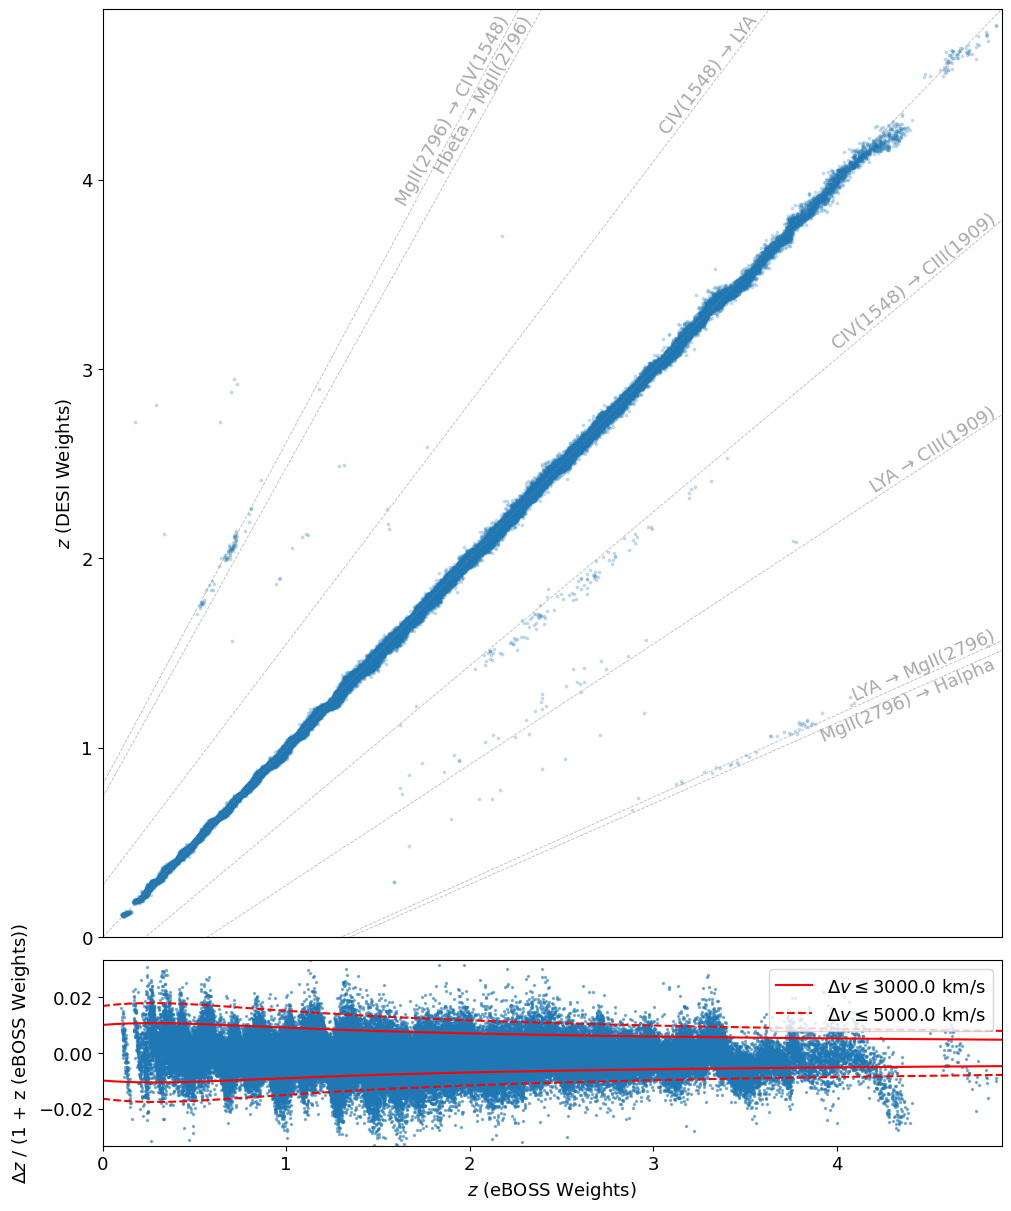

In [30]:
fig, ax = plt.subplots(2, 1, figsize=(10, 12), layout="constrained", height_ratios=[1, 0.2])
# fig = plt.figure(figsize=(10, 10), layout="constrained")

# plt.rcParams.update({
#     "text.usetex": False,
#     "font.family": "DejaVu Sans"
# })

# ax[0] = plt.subplot(5, 5, (6, 24))

# only plot points that both networks thought are quasars
both_qso = j["IS_QSO_NEW"] & j["IS_QSO_OLD"]
z_eboss = j["ZBEST_OLD"][both_qso]
z_desi = j["ZBEST_NEW"][both_qso]
z_lim = np.ceil(np.max(z_eboss) * 10) / 10


ax[0].scatter(z_eboss, z_desi, s=3, alpha=0.2)
ax[0].plot([0, z_lim], [0, z_lim], c="grey", alpha=0.5, ls="dashed", lw=0.65)
ax[0].set(xlim=(0, z_lim), ylim=(0, z_lim), ylabel="$z$ (DESI Weights)")

# Code for plotting the confusion lines
x_1 = np.asarray([0,7])
points = (np.abs(z_eboss - 1.8) <= 0.3) & (np.abs(z_desi - 1) <= 0.2) 

# TODO: What does this... do?
# slope = np.dot(z_eboss, z_desi) / np.dot(z_eboss, z_eboss)
# idx = np.argmin(np.abs(confusion_nums - slope))

ylim = ax[0].get_ylim()
# xlim = ax[0].get_xlim()
x_p = np.asarray([0, z_lim])

confusions = [3, 23, 2, 6, 8, 27, 19] 

for idx in confusions:
    idx_2d = np.unravel_index(idx, shape=slopes.shape)
    
    m = slopes[idx_2d]
    b = intercepts[idx_2d]
      
    text_string = f"{line_and_wave[idx_2d[0]]} → {line_and_wave[idx_2d[1]]}"
    ax[0].plot(x_p, m * x_p + b, c="grey", alpha=0.5, ls="dashed", lw=0.65)
    
    # Below the 45 the right edge of the line is going to be at the xlimit
    # So use that for the x coord and calculate the y coord, then 
    # offset it above the line
    x_1 = z_lim - 0.04
    y_1 = m * x_1 + 0.05 + b
    
    if line_and_wave[idx_2d[1]] == "Halpha":
         y_1 = m * x_1 - 0.05 + b
    
    if y_1 > ylim[-1]:
        y_1 = z_lim - 0.04
        x_1 = (y_1 - b) / m - 0.05
        
    theta = np.rad2deg(np.arctan(m))
    
    ax[0].text(x_1, y_1, text_string, ha="right", va="center", rotation_mode="anchor", rotation=theta, c="darkgrey")
    
# X and Y lims get reset by the line confusions to this resets it back
ax[0].set(xlim=(0, z_lim), ylim=(0, z_lim))
ax[0].xaxis.set_visible(False)

# Lower plot
ax[1].scatter(z_eboss, (z_desi - z_eboss) / (1 + z_eboss), s=2, alpha=0.5)

# Contours for velocity agreement in the lower plot
# colors = ["r", "magenta"]
styles = ["solid", "dashed"]
for i, delta_v in enumerate([3e3, 5e3]):
    z_v_upper = z_v(v_z(z_p) + delta_v)
    z_v_lower = z_v(v_z(z_p) - delta_v)
    ax[1].plot(z_p, (z_v_upper - z_p)/(1 + z_p), ls=styles[i], label=f"$\Delta v \leq {delta_v}$ km/s", c="red")
    ax[1].plot(z_p, (z_v_lower - z_p)/(1 + z_p), ls=styles[i], c="red")
    
    right_edge = ((z_v_lower - z_p)/(1 + z_p))[-1]
    # ax[1].text(z_lim - 0.05, right_edge - 4e-3 * (i + 1), f"$\Delta_v \leq {delta_v}$ km/s", c=colors[i], ha="right", va="top")


ax[1].set(xlim=(0, z_lim), ylim=(-10e3/c_light, 10e3/c_light), xlabel="$z$ (eBOSS Weights)", ylabel="$\Delta z$ / (1 + z (eBOSS Weights))")
ax[1].legend(loc="upper right")
# ax[1].text(z_lim - 0.05, -10e3 / c + 1e-3, f"$\Delta_v \leq {10e3}$ km/s", c="black", ha="right")

plt.savefig("plots/redshift_diff.jpg", bbox_inches="tight", dpi=256)

In [31]:
v_eboss = v_z(z_eboss)
v_desi = v_z(z_desi)

In [32]:
np.sum(np.abs(v_desi - v_eboss) < 3e3) / len(z_eboss), np.sum(np.abs(v_desi - v_eboss) < 5e3) / len(z_eboss)

(0.8900356150311078, 0.9758994751290067)

In [33]:
joined_grouped = join(grouped_table_old, grouped_table_new, "TARGETID", table_names=["OLD", "NEW"])

In [34]:
_, counts_join = np.unique(joined_grouped["TARGETID"], return_counts=True)

class_old = structured_to_unstructured(np.asarray(joined_grouped["IS_QSO_OLD", "NOT_QSO_OLD"]))
confs_old = class_old / np.sum(class_old, axis=1)[:, None]
H_old = calc_entropy(confs_old)

class_new = structured_to_unstructured(np.asarray(joined_grouped["IS_QSO_NEW", "NOT_QSO_NEW"]))
confs_new = class_new / np.sum(class_new, axis=1)[:, None]
H_new = calc_entropy(confs_new)

/tmp/ipykernel_233173/3601029387.py:2: RuntimeWarning: divide by zero encountered in log
  H = confidence * np.log(confidence) / np.log(2)
/tmp/ipykernel_233173/3601029387.py:2: RuntimeWarning: invalid value encountered in multiply
  H = confidence * np.log(confidence) / np.log(2)
/tmp/ipykernel_233173/3601029387.py:2: RuntimeWarning: divide by zero encountered in log
  H = confidence * np.log(confidence) / np.log(2)
/tmp/ipykernel_233173/3601029387.py:2: RuntimeWarning: invalid value encountered in multiply
  H = confidence * np.log(confidence) / np.log(2)


In [35]:
np.asarray(grouped_table_old["IS_QSO", "NOT_QSO"])

array([(0, 2), (0, 2), (0, 2), ..., (0, 3), (0, 3), (0, 3)],
      dtype=[('IS_QSO', '<i8'), ('NOT_QSO', '<i8')])

In [36]:
colors = ["#5790fc", "#964a8b", "#e42536", "#f89c20"]

/tmp/ipykernel_233173/2461135841.py:16: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax[1].set(yscale="log", xlabel="Confusion", xlim=(0.2, bins[-1]), ylim=(ax[1].get_ylim()[0], 5e4))


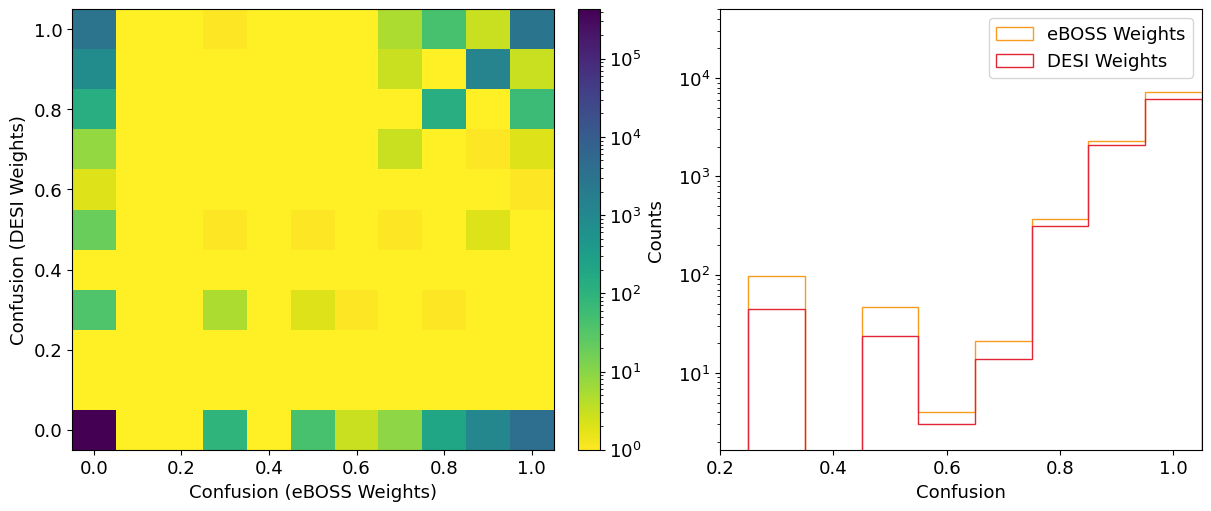

In [37]:
bins = np.arange(-0.05, 1.1, 0.1)
fig, ax = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")

cmap = plt.cm.viridis.reversed()
h = ax[0].hist2d(H_old, H_new, bins=bins, norm="log", cmin=0, cmap=cmap)

cbar = fig.colorbar(h[3], ax=ax[0])
cbar.ax.set_ylabel("Counts")

ax[0].set_xlabel("Confusion (eBOSS Weights)")
ax[0].set_ylabel("Confusion (DESI Weights)")
ax[0].set_facecolor(np.array([255, 240, 38]) / 255)

n_old, *_ = ax[1].hist(H_old, bins=bins, histtype="step", label="eBOSS Weights", ec=colors[3])
n_new, *_ = ax[1].hist(H_new, bins=bins, histtype="step", label="DESI Weights", ec=colors[2])
ax[1].set(yscale="log", xlabel="Confusion", xlim=(0.2, bins[-1]), ylim=(ax[1].get_ylim()[0], 5e4))
ax[1].legend()
plt.savefig("plots/confusion.pdf", bbox_inches="tight")

In [38]:
mult_tids_joined, c_j = np.unique(j[j["IS_QSO_NEW"]]["TARGETID"], return_counts=True)
mult_exps_joined = mult_tids_joined[c_j > 1]
idcs_joined = np.isin(j[j["IS_QSO_NEW"]]["TARGETID"], mult_exps_joined)

In [39]:
grouped_j = j["TARGETID", "ZBEST_NEW"][j["IS_QSO_NEW"]][idcs_joined].group_by("TARGETID")

# Run the aggregating operations here
std_group_new = grouped_j.groups.aggregate(np.std)
mean_group_new = grouped_j.groups.aggregate(np.mean)
std_group_new.rename_column("ZBEST_NEW", "ZBEST_STD")
mean_group_new.rename_column("ZBEST_NEW", "ZBEST_MEAN")

grouped_j

TARGETID,ZBEST_NEW
int64,float64
39627571582730783,1.6943552298020341
39627571582730783,1.6945212992821315
39627571582731105,1.0862896716648862
39627571582731105,1.0982065370771514
39627571582731334,2.958167811851227
39627571582731334,2.955895443885626
39627571582731444,1.56750669811776
39627571582731444,1.5627923422349959
39627571591119365,3.210246374609116


In [40]:
mult_tids_joined, c_j = np.unique(j[j["IS_QSO_OLD"]]["TARGETID"], return_counts=True)
mult_exps_joined = mult_tids_joined[c_j > 1]
idcs_joined = np.isin(j[j["IS_QSO_OLD"]]["TARGETID"], mult_exps_joined)

In [41]:
grouped_j = j["TARGETID", "ZBEST_OLD"][j["IS_QSO_OLD"]][idcs_joined].group_by("TARGETID")

# Run the aggregating operations here
std_group_old = grouped_j.groups.aggregate(np.std)
mean_group_old = grouped_j.groups.aggregate(np.mean)
std_group_old.rename_column("ZBEST_OLD", "ZBEST_STD")
mean_group_old.rename_column("ZBEST_OLD", "ZBEST_MEAN")

grouped_j

TARGETID,ZBEST_OLD
int64,float64
-809798367,0.9992085159097062
-809798367,2.6316983001684076
-809795243,2.4464748434081742
-809795243,2.3784338245802736
-207286176,3.7932262313373455
-207286176,3.801246690439865
-204188056,3.790055266240415
-204188056,2.076352058741286
39627571582731105,1.1039768839899415


In [42]:
z_mults_new = join(std_group_new, mean_group_new, "TARGETID")
z_mults_new

TARGETID,ZBEST_STD,ZBEST_MEAN
int64,float64,float64
39627571582730783,8.303474004867084e-05,1.6944382645420828
39627571582731105,0.00595843270613261,1.0922481043710188
39627571582731334,0.001136183982800576,2.9570316278684263
39627571582731444,0.002357177941382016,1.5651495201763779
39627571591119365,0.004353170696321573,3.2145995453054375
39627571591120065,0.00650739346067386,0.8802852540056054
39627571595313521,0.006413055658648581,1.766304475221549
39627571599507732,0.00034640286171949697,1.709461492761776
39627571603702043,0.0013850750875024076,1.8472213927507188


In [43]:
z_mults_old = join(std_group_old, mean_group_old, "TARGETID")
z_mults_old

TARGETID,ZBEST_STD,ZBEST_MEAN
int64,float64,float64
-809798367,0.8162448921293507,1.815453408039057
-809795243,0.034020509413950295,2.4124543339942237
-207286176,0.004010229551259847,3.7972364608886053
-204188056,0.8568516037495646,2.9332036624908504
39627571582731105,0.0014968606274572416,1.1024800233624843
39627571582731334,0.0006674250743283761,2.964411492697744
39627571582731444,0.004218240951320729,1.5660874923496981
39627571591119365,0.00027535785655574685,3.2172181642583433
39627571599507732,0.0028421705146191023,1.7062252348331381


Text(0.5, 1.0, 'std for z estimates from repeat exposures')

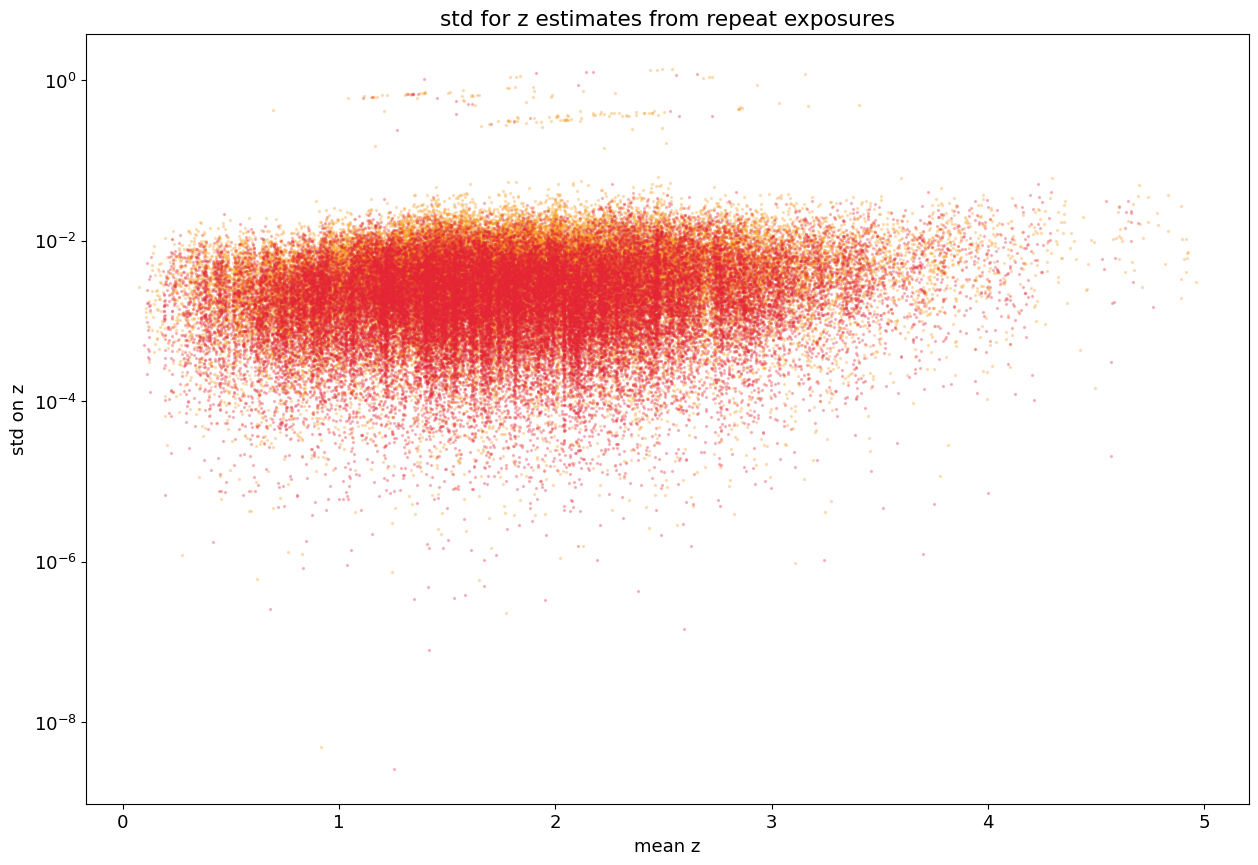

In [44]:
fig, ax = plt.subplots(figsize=(15, 10))

plt.scatter(z_mults_old["ZBEST_MEAN"], z_mults_old["ZBEST_STD"], s=2, alpha=0.25, c=colors[3])
plt.scatter(z_mults_new["ZBEST_MEAN"], z_mults_new["ZBEST_STD"], s=2, alpha=0.25, c=colors[2])

plt.yscale("log")
plt.xlabel("mean z")
plt.ylabel("std on z")
plt.title("std for z estimates from repeat exposures")
# plt.savefig("plots/std_z.jpg", dpi=256, bbox_inches="tight")

In [45]:
def mean_bin(bins, z_tbl):
    mean_z_per_bin = []
    std_z_per_bin = []
    for i in range(len(bins) - 1):
        in_bin = (z_tbl["ZBEST_MEAN"] >= bins[i]) & (z_tbl["ZBEST_MEAN"] < bins[i + 1])
        mean_z_per_bin.append(np.nanmean(z_tbl["ZBEST_STD"][in_bin]))
        std_z_per_bin.append(np.nanstd(z_tbl["ZBEST_STD"][in_bin]))
    return mean_z_per_bin, std_z_per_bin

In [46]:
bins = np.linspace(0, 5, 20)
mean_old, std_old = mean_bin(bins, z_mults_old)
mean_new, std_new = mean_bin(bins, z_mults_new)

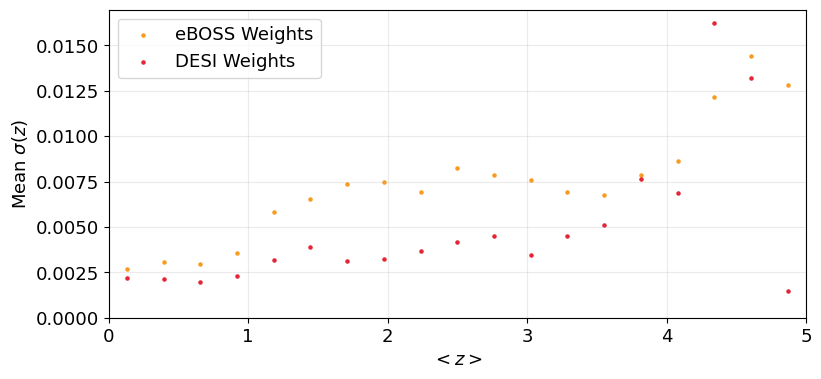

In [47]:
fig, ax = plt.subplots(figsize=(9, 4))
mids = bins[:-1] + np.diff(bins) / 2

plt.scatter(mids, mean_old, label="eBOSS Weights", s=5, c=colors[3])
plt.scatter(mids, mean_new, label="DESI Weights", s=5, c=colors[2])

# plt.errorbar(mids, mean_old, std_old, label="eBOSS Weights", marker="o")
# plt.errorbar(mids, mean_new, std_new, label="DESI Weights", marker="o")

plt.ylabel("Mean $\sigma(z)$")
plt.xlabel("$<z>$")
plt.legend(loc="upper left")
# plt.title("Median Binned $\sigma$ for z Estimates From Repeat Exposures")

plt.ylim(0, None)
plt.xlim(bins[0], bins[-1])
plt.grid(alpha=0.25)

plt.savefig("plots/binned_std_z.pdf", bbox_inches="tight")